In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt
from astropy.io import fits
from lmfit.model import load_modelresult


In [2]:
# For manual stuff (added manually)
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\multiple_lines_phd\MUSE_30dor\py_modules")
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\multiple_lines_phd\MUSE_30dor")

from pipeline_config import MAPS_DIR, STRUCTURE_DIR, FIGS_DIR 
import results_comp
import plot_fit_params
import ci_results_compiler

In [3]:
H_file_name = "MUSE-Dor-H-bin0"
#O_file_name = "MUSE-N346-O"
N_file_name = "MUSE-Dor-N-bin0"
Nw_file_name = "MUSE-Dor-N-bin0-w"
N1_file_name = "MUSE-Dor-N-bin1"
N1w_file_name = "MUSE-Dor-N-bin1-w"

#S_file_name = "MUSE-N346-S"

labels = ['H',
          #'O', 
          'N',
          'N1',
          'Nw',
          'N1w'
         ]

In [4]:
H_ = results_comp.load_line_bundle_mat(H_file_name, "H_line", MAPS_DIR, read_header=True)
#O_ = results_comp.load_line_bundle_mat(O_file_name, "O_line", MAPS_DIR, read_header=True)
N_ = results_comp.load_line_bundle_mat(N_file_name, "N_line", MAPS_DIR, read_header=True)
N_1 = results_comp.load_line_bundle_mat(N1_file_name, "N1_line", MAPS_DIR, read_header=True)
#S_ = results_comp.load_line_bundle_mat(S_file_name, "S_line", MAPS_DIR, read_header=True)

obs = [
    H_['meta']['SIG2'], 
    N_['meta']['SIG2'],
    N_1['meta']['SIG2'],
    N_['meta']['SIG2'],
    N_1['meta']['SIG2'],
    # S_['meta']['SIG2']
]


In [5]:
# H
name = H_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

H_line = ci_results_compiler.ci_results_compiler(fit_Br)

In [6]:
# N
name = N_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

N_line = ci_results_compiler.ci_results_compiler(fit_Br)

In [7]:
# N downsample
name = N1_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

N1_line = ci_results_compiler.ci_results_compiler(fit_Br)

In [8]:
# N weighted
name = Nw_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

Nw_line = ci_results_compiler.ci_results_compiler(fit_Br)

In [9]:
# N downsample-weighted
name = N1w_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

N1w_line = ci_results_compiler.ci_results_compiler(fit_Br)

# Plots

In [10]:
H_mask = (H_['mask'] !=0)
N_mask = (N_['mask'] !=0)
#S_mask = (S_['mask'] !=0)
#O_mask = (O_['mask'] !=0)

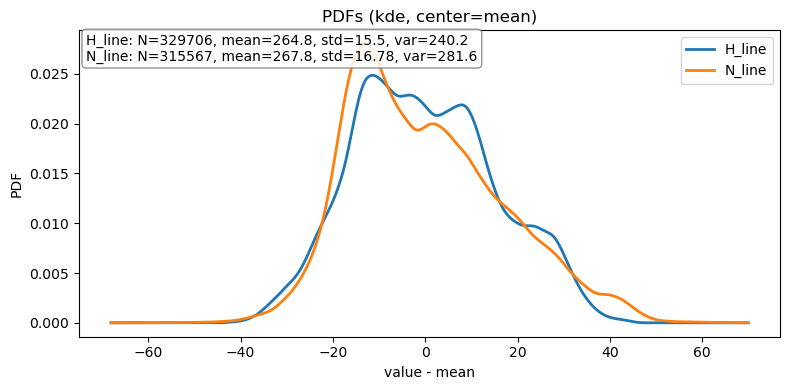

In [11]:
import matrix_plots  # if you’ll place this function inside that module

arrays = {"H_line": H_["vv"][H_mask], "N_line": N_["vv"][N_mask]}
fig, ax = matrix_plots.plot_pdfs(arrays, center="mean", method="kde", bw_scale=1.0)
plt.savefig('Imgs/pdfs.jpg', bbox_inches='tight')

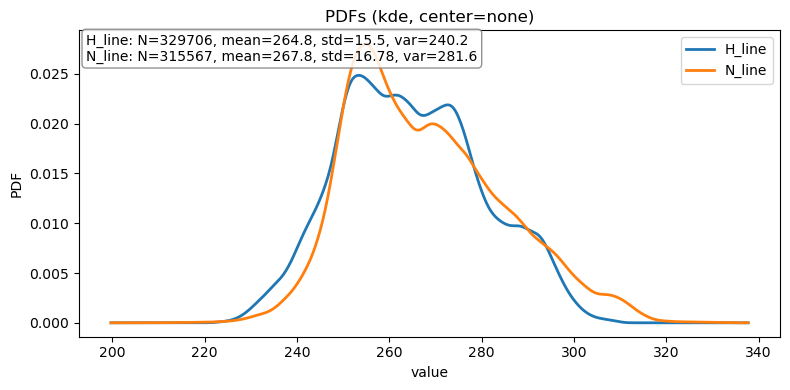

In [12]:
arrays = {"H_line": H_["vv"][H_mask], "N_line": N_["vv"][N_mask]}
fig, ax = matrix_plots.plot_pdfs(arrays, method="kde", bw_scale=1.0)

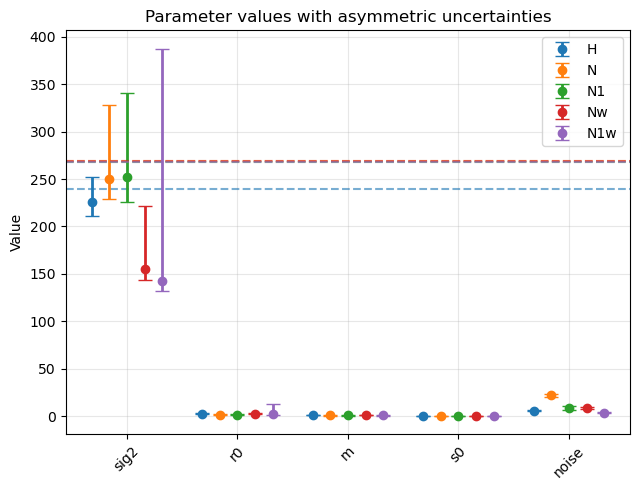

In [13]:

plot_fit_params.plot_param_comp_obs(H_line, N_line, N1_line, Nw_line, N1w_line, labels=labels, obs=obs)

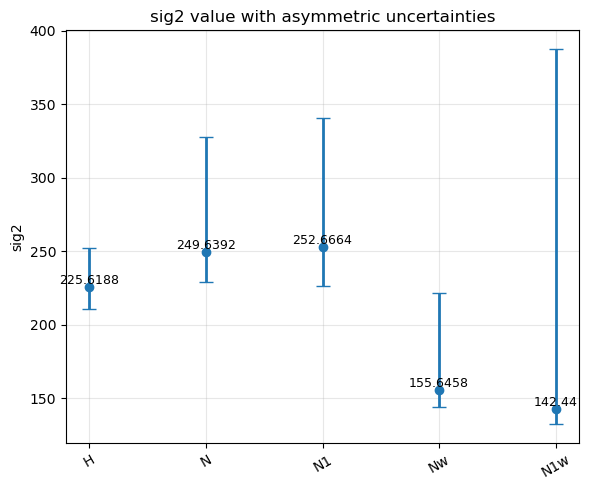

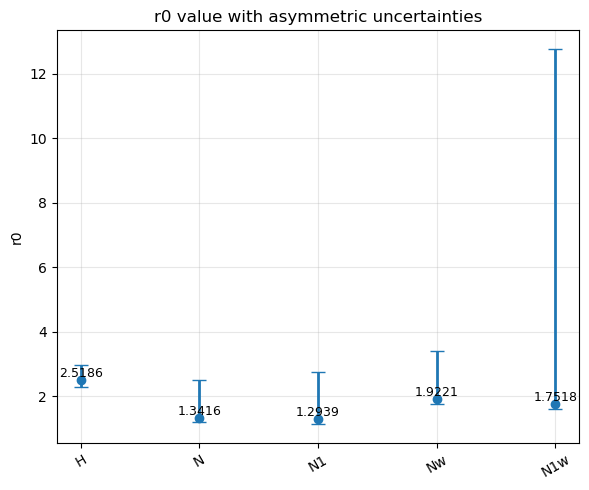

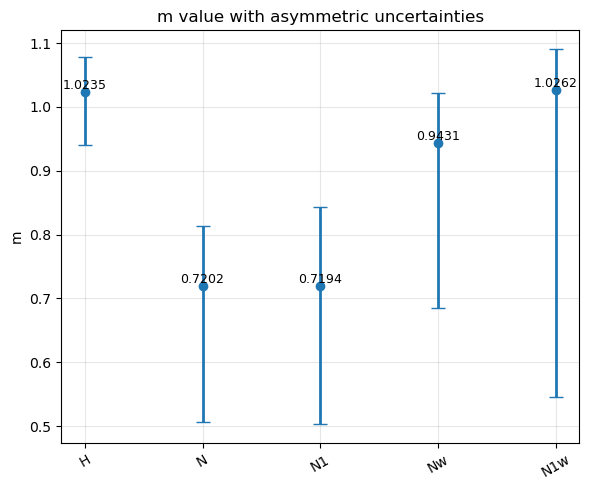

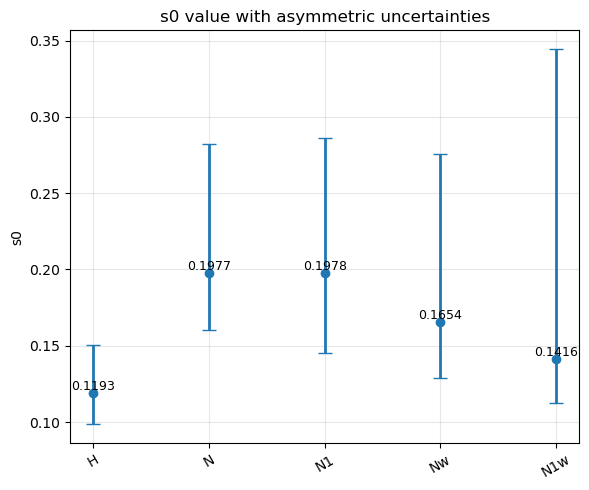

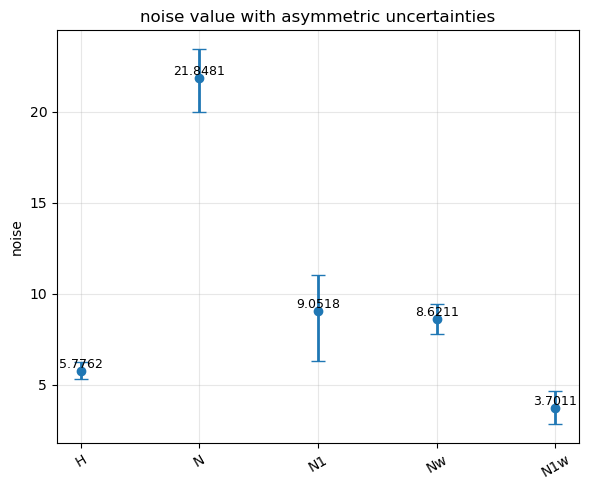

In [14]:
plot_fit_params.plot_param(H_line, N_line, N1_line, Nw_line, N1w_line, labels=labels,
                                decimals=4)
